# Polymarket Prediction Markets: High-Liquidity Crypto Event Contracts

**Chapter 4: Fundamental and Alternative Data**
**Docker image**: `ml4t`

## Purpose

Polymarket is the world's largest prediction market by trading volume, operating
on the Polygon blockchain with USDC settlement. This notebook loads pre-downloaded
Polymarket OHLCV data from the centralized data pipeline and compares it with the
Kalshi data from the previous notebook to illustrate cross-platform differences in
liquidity, pricing, and market structure. An optional live API demo is available
for interactive use but disabled by default for automated runs.

## Learning Objectives

After completing this notebook, you will be able to:
- Understand Polymarket contract structure and crypto mechanics
- Load and explore pre-downloaded Polymarket OHLCV data
- Compare Polymarket vs Kalshi on overlapping markets (Fed rate decisions)
- Build implied probability indicators from prediction market OHLCV

## Cross-References

- **Upstream**: `data/prediction_markets/download.py` (batch downloads)
- **Downstream**: Chapter 8 event features, macro regime indicators
- **Related**: [`12_kalshi_prediction_markets`](12_kalshi_prediction_markets.ipynb) (CFTC-regulated alternative)

In [1]:
"""Polymarket Prediction Markets — compare crypto-based event contracts with Kalshi for ML feature engineering."""

import warnings

warnings.filterwarnings("ignore")

import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from data.prediction_markets.loader import load_kalshi, load_polymarket
from utils.paths import get_output_dir
from utils.style import COLORS

In [2]:
# Production defaults — Papermill injects overrides for CI
LIVE = False

## 1. Polymarket Contract Structure

Polymarket uses conditional tokens on the Polygon blockchain.
Each market has YES and NO outcome tokens that trade against USDC.

| Feature | Description |
|---------|-------------|
| **Settlement** | USDC (stablecoin) |
| **Position Limit** | None |
| **Trading** | 24/7 |
| **Fees** | Maker rebates, taker fees (~1-2%) |
| **Min Order** | ~$1 |

### Polymarket vs Kalshi

| Aspect | Polymarket | Kalshi |
|--------|------------|--------|
| **Regulation** | Unregulated | CFTC-regulated |
| **Liquidity** | Higher | Lower |
| **US Access** | Restricted | Yes |
| **Settlement** | USDC (crypto) | USD (fiat) |
| **Position Limits** | None | \$25,000 |

## 2. Load Polymarket Data

We load pre-downloaded OHLCV data produced by
`data/prediction_markets/download.py`. This keeps Chapter 4 notebooks aligned
with the centralized data workflow used elsewhere in the book.

In [3]:
df = load_polymarket()

print(f"Loaded {len(df):,} observations across {df['symbol'].n_unique()} markets")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")

df.group_by("symbol").len().rename({"len": "days"}).sort("symbol")

Loaded 22 observations across 15 markets
Date range: 2026-05-01 to 2026-05-02


symbol,days
str,u32
"""BITCOIN-ABOVE-70K-ON-MAY-2:YES""",1
"""BITCOIN-ABOVE-72K-ON-MAY-2:YES""",1
"""BITCOIN-ABOVE-80K-ON-MAY-2:YES""",2
"""BITCOIN-ABOVE-84K-ON-MAY-2:YES""",1
"""JEROME-POWELL-OUT-AS-FED-CHAIR…",2
…,…
"""WILL-TESLA-BE-THE-LARGEST-COMP…",1
"""WILL-TESLA-BE-THE-LARGEST-COMP…",1
"""WILL-THE-FED-DECREASE-INTEREST…",2


## 3. Contract Universe

The downloaded dataset contains daily OHLCV bars for curated, non-political
Polymarket contracts. The `close` price is the implied probability of the YES
outcome. We summarize the downloaded universe before comparing it with Kalshi.

In [4]:
# Map every contract into the four trading-relevant buckets the chapter
# discusses (monetary_policy, crypto, commodities, geopolitics) using a
# native polars regex chain — no Python UDF. The inference takes
# precedence over the loader's coarser provider category (e.g. an
# "economics" Fed-rate contract maps to monetary_policy here) so that
# the cross-platform Fed comparison below picks it up. Anything that
# doesn't match falls back to the provider category, then to "other".
slug = pl.col("symbol").str.to_lowercase().str.replace_all("-", " ")
inferred_category = (
    pl.when(slug.str.contains(r"\b(fed|interest rate|fomc|inflation|cpi|gdp)\b"))
    .then(pl.lit("monetary_policy"))
    .when(slug.str.contains(r"\b(bitcoin|btc|ethereum|eth|crypto|solana)\b"))
    .then(pl.lit("crypto"))
    .when(slug.str.contains(r"\b(crude oil|gold|s&p|nasdaq|spy|stock)\b"))
    .then(pl.lit("commodities"))
    .when(slug.str.contains(r"\b(iran|china|russia|war|ceasefire|ukraine)\b"))
    .then(pl.lit("geopolitics"))
    .otherwise(None)
)

df = df.with_columns(
    pl.coalesce(inferred_category, pl.col("category"), pl.lit("other")).alias("market_category"),
    (pl.col("high") - pl.col("low")).alias("intraday_range"),
    (pl.col("close") - 0.5).abs().alias("conviction"),
    ((pl.col("close") > 0.8) | (pl.col("close") < 0.2)).cast(pl.Int8).alias("high_confidence"),
)

contracts = (
    df.group_by(["symbol", "market_category"])
    .agg(
        pl.col("close").first().alias("initial_prob"),
        pl.col("close").last().alias("latest_prob"),
        pl.col("volume").sum().alias("total_volume"),
        pl.col("intraday_range").mean().alias("avg_intraday_range"),
        pl.col("timestamp").min().alias("first_date"),
        pl.col("timestamp").max().alias("last_date"),
        pl.len().alias("observations"),
    )
    .sort("total_volume", descending=True)
)
contracts

symbol,market_category,initial_prob,latest_prob,total_volume,avg_intraday_range,first_date,last_date,observations
str,str,f64,f64,f64,f64,date,date,u32
"""BITCOIN-ABOVE-84K-ON-MAY-2:YES""","""crypto""",0.0015,0.0015,62.0,0.001,2026-05-02,2026-05-02,1
"""WILL-TESLA-BE-THE-LARGEST-COMP…","""technology""",0.0015,0.0015,62.0,0.0,2026-05-02,2026-05-02,1
"""WILL-JUDY-SHELTON-BE-CONFIRMED…","""monetary_policy""",0.0035,0.0035,62.0,0.0,2026-05-01,2026-05-02,2
"""BITCOIN-ABOVE-72K-ON-MAY-2:YES""","""crypto""",0.9985,0.9985,62.0,0.0,2026-05-02,2026-05-02,1
"""WILL-OPENAI-HAVE-THE-BEST-AI-M…","""technology""",0.034,0.034,62.0,0.001,2026-05-02,2026-05-02,1
…,…,…,…,…,…,…,…,…
"""WILL-TESLA-BE-THE-LARGEST-COMP…","""technology""",0.0035,0.0035,62.0,0.0,2026-05-02,2026-05-02,1
"""WILL-THE-FED-INCREASE-INTEREST…","""monetary_policy""",0.0075,0.0075,62.0,0.0,2026-05-01,2026-05-02,2
"""WILL-BITCOIN-HIT-150K-BY-JUNE-…","""crypto""",0.0205,0.0175,61.0,0.0015,2026-05-01,2026-05-02,2


The centralized download focuses on curated, non-political contracts with
useful history. This is a better fit for reproducible notebook execution than
querying whatever happens to be live on Polymarket at run time.

## 4. Categorizing Markets

We compare the downloaded Polymarket markets by broad event category.

In [5]:
category_stats = (
    contracts.group_by("market_category")
    .agg(
        pl.len().alias("n_markets"),
        pl.col("total_volume").sum().alias("total_volume"),
        pl.col("avg_intraday_range").mean().alias("avg_intraday_range"),
        pl.col("latest_prob").mean().alias("avg_latest_prob"),
    )
    .sort("total_volume", descending=True)
)
category_stats

market_category,n_markets,total_volume,avg_intraday_range,avg_latest_prob
str,u32,f64,f64,f64
"""crypto""",5,309.0,0.0038,0.4123
"""monetary_policy""",5,309.0,0.0006,0.0167
"""technology""",3,186.0,0.000333,0.013
"""science""",2,123.0,0.0,0.46275


## 5. Implied Probability Distribution

The closing price is the market's implied probability of the event occurring.
We visualize the latest contract probabilities across the downloaded universe.

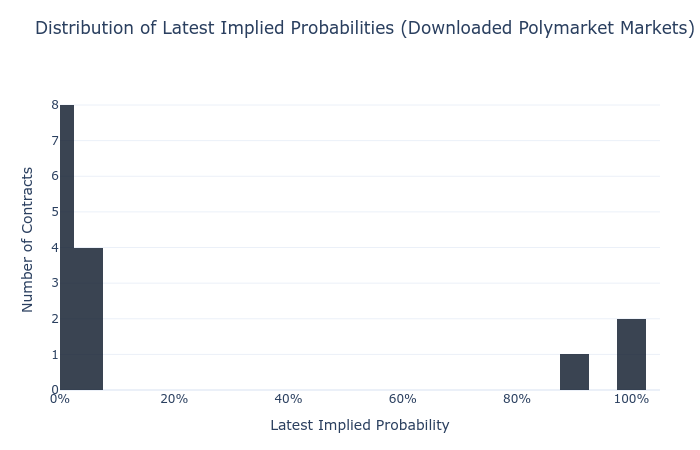

In [6]:
valid_prices = contracts.filter(pl.col("latest_prob").is_not_null())

fig = go.Figure()

fig.add_trace(
    go.Histogram(
        x=valid_prices["latest_prob"].to_list(),
        nbinsx=20,
        marker_color=COLORS["blue"],
        opacity=0.8,
    )
)

fig.update_layout(
    title=dict(
        text="Distribution of Latest Implied Probabilities (Downloaded Polymarket Markets)",
        y=0.95,
    ),
    xaxis_title="Latest Implied Probability",
    yaxis_title="Number of Contracts",
    xaxis=dict(tickformat=".0%", range=[0, 1.05]),
    template="plotly_white",
    height=450,
    margin=dict(t=90, b=60, l=60, r=40),
)

fig.show()

Contracts near 0 or 1 reflect near-consensus outcomes. The contracts between
0.2 and 0.8 are where genuine uncertainty exists and where prediction market
signals are typically most useful for feature engineering.

## 6. Volume vs Intraday Range

In the current snapshot, the downloaded universe has 1-2 daily bars per
market, so per-contract total volume is essentially constant across rows
(the sum-of-bars proxy clusters in a narrow band) and the corresponding
scatter degenerates into a vertical strip. Rather than ship a misleading
visual, we report the same information as a table: contracts ranked by
average intraday range within each category. When the downloader window
is widened (more bars per market), the scatter regains its usual
volume-vs-volatility spread.

In [7]:
category_colors = {
    "monetary_policy": COLORS["amber"],
    "crypto": COLORS["slate"],
    "commodities": COLORS["blue"],
    "geopolitics": COLORS.get("rose", "#e11d48"),
    "other": "#94a3b8",
}

contracts.select(
    "symbol",
    "market_category",
    "total_volume",
    "avg_intraday_range",
).sort("avg_intraday_range", descending=True).head(10)

symbol,market_category,total_volume,avg_intraday_range
str,str,f64,f64
"""BITCOIN-ABOVE-80K-ON-MAY-2:YES""","""crypto""",62.0,0.0165
"""JEROME-POWELL-OUT-AS-FED-CHAIR…","""monetary_policy""",62.0,0.003
"""WILL-BITCOIN-HIT-150K-BY-JUNE-…","""crypto""",61.0,0.0015
"""WILL-OPENAI-HAVE-THE-BEST-AI-M…","""technology""",62.0,0.001
"""BITCOIN-ABOVE-84K-ON-MAY-2:YES""","""crypto""",62.0,0.001
"""WILL-TESLA-BE-THE-LARGEST-COMP…","""technology""",62.0,0.0
"""WILL-JUDY-SHELTON-BE-CONFIRMED…","""monetary_policy""",62.0,0.0
"""BITCOIN-ABOVE-72K-ON-MAY-2:YES""","""crypto""",62.0,0.0
"""BITCOIN-ABOVE-70K-ON-MAY-2:YES""","""crypto""",62.0,0.0


High-volume, high-range contracts are the ones where new information moved
probabilities meaningfully — the natural candidates for event features or
cross-platform comparison.

## 7. Probability Evolution

The downloaded OHLCV data lets us inspect how probability evolved through
time for the most active contracts.

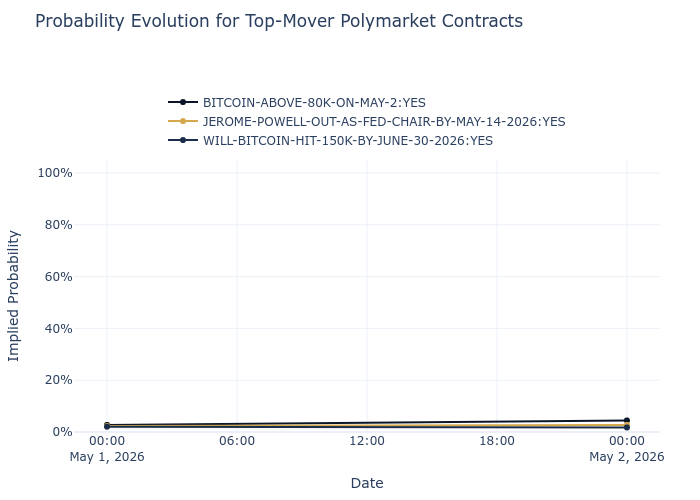

In [8]:
# Pick the three contracts whose probability moved most over the snapshot
# (largest |latest_prob - initial_prob|). Picking by total_volume can land
# on contracts that flat-lined near 0 or 1 across both available bars,
# producing a near-blank chart.
movers = (
    contracts.with_columns(
        (pl.col("latest_prob") - pl.col("initial_prob")).abs().alias("abs_move"),
    )
    .filter(pl.col("latest_prob").is_not_null() & pl.col("initial_prob").is_not_null())
    .sort("abs_move", descending=True)
    .head(3)
)
top_contracts = movers["symbol"].to_list()

fig = go.Figure()
palette = [COLORS["blue"], COLORS["amber"], COLORS["slate"]]

for sym, color in zip(top_contracts, palette, strict=False):
    data = df.filter(pl.col("symbol") == sym).sort("timestamp").to_pandas()
    label = sym[:50] + "..." if len(sym) > 50 else sym
    fig.add_trace(
        go.Scatter(
            x=data["timestamp"],
            y=data["close"],
            mode="lines+markers",
            name=label,
            line=dict(color=color, width=2),
        )
    )

fig.update_layout(
    title=dict(
        text="Probability Evolution for Top-Mover Polymarket Contracts",
        y=0.97,
    ),
    xaxis_title="Date",
    yaxis_title="Implied Probability",
    yaxis=dict(tickformat=".0%", range=[0, 1.05]),
    template="plotly_white",
    height=500,
    margin=dict(t=160, b=60, l=60, r=40),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
)

fig.show()

The snapshot bundled with the book covers a 24-hour window with one or two
daily bars per contract, so the trajectories appear close to flat: the
downloader is configured for a reproducible smoke test, not a long history.
Widen the window via the downloader's `--max-markets-per-category` and
`--search-results-per-query` flags to surface multi-week histories. The
most informative contracts are those that both moved materially and stayed
away from the trivial 0 or 1 endpoints for part of the sample.

## 8. Optional Live Market Discovery Demo

The main notebook path should use the centralized downloads. For interactive
exploration, set `LIVE=True` via papermill or in the notebook to inspect the
current Polymarket market universe without affecting routine test runs.

In [9]:
live_snapshot = None

if LIVE:
    from ml4t.data.providers.polymarket import PolymarketProvider

    provider = PolymarketProvider()
    live_markets = provider.list_markets(active=True, closed=False, limit=200)
    provider.close()

    live_snapshot = pl.DataFrame(
        {
            "slug": [m.get("slug", "") for m in live_markets],
            "question": [m.get("question", "")[:80] for m in live_markets],
            "volume": [float(m.get("volume", 0)) for m in live_markets],
            "liquidity": [float(m.get("liquidity", 0)) for m in live_markets],
        }
    ).sort("volume", descending=True)

    print(f"LIVE=True: fetched {len(live_snapshot)} active Polymarket markets")
else:
    print("LIVE=False: skipping live Polymarket API demo")

live_snapshot.head(10) if live_snapshot is not None else None

LIVE=False: skipping live Polymarket API demo


## 9. Fed Rate Markets — Cross-Platform Comparison

Both Polymarket and Kalshi offer binary contracts on Federal Reserve
rate decisions. This creates a natural cross-platform comparison. We
load the Kalshi OHLCV data from disk (see notebook 13) and compare it
with downloaded Polymarket monetary-policy contracts.

In [10]:
kalshi_df = load_kalshi()

print(f"Kalshi: {len(kalshi_df):,} observations, {kalshi_df['symbol'].n_unique()} contracts")
print(f"Date range: {kalshi_df['timestamp'].min()} to {kalshi_df['timestamp'].max()}")

Kalshi: 687 observations, 9 contracts
Date range: 2025-10-07 to 2025-12-31


In [11]:
fed_markets = contracts.filter(pl.col("market_category") == "monetary_policy")

print(f"Polymarket Fed/Macro markets: {len(fed_markets)}")

fed_markets.select("symbol", "latest_prob", "total_volume", "avg_intraday_range")

Polymarket Fed/Macro markets: 5


symbol,latest_prob,total_volume,avg_intraday_range
str,f64,f64,f64
"""WILL-JUDY-SHELTON-BE-CONFIRMED…",0.0035,62.0,0.0
"""JEROME-POWELL-OUT-AS-FED-CHAIR…",0.0275,62.0,0.003
"""WILL-THE-FED-DECREASE-INTEREST…",0.0045,62.0,0.0
"""WILL-THE-FED-INCREASE-INTEREST…",0.0075,62.0,0.0
"""WILL-THE-FED-DECREASE-INTEREST…",0.0405,61.0,0.0


## 10. Kalshi Rate Threshold Probabilities

Kalshi offers multiple threshold contracts per FOMC meeting (e.g., rate
above 4.00%, 4.25%, 4.50%). These form a probability distribution over
rate outcomes. We visualize the latest Kalshi prices alongside the latest
downloaded Polymarket monetary-policy probabilities.

In [12]:
kalshi_latest = (
    kalshi_df.sort("timestamp")
    .group_by("symbol")
    .agg(
        pl.col("close").last().alias("kalshi_prob"),
        pl.col("volume").sum().alias("kalshi_volume"),
        pl.col("timestamp").max().alias("last_date"),
    )
    .sort("symbol")
)
kalshi_latest

symbol,kalshi_prob,kalshi_volume,last_date
str,f64,f64,date
"""KXFED-27APR-T0.25""",0.92,0.0,2025-12-31
"""KXFED-27APR-T2.25""",0.74,0.0,2025-12-31
"""KXFED-27APR-T3.75""",0.14,2.0,2025-12-31
"""KXFED-27APR-T4.00""",0.06,0.0,2025-12-31
"""KXFED-27APR-T4.25""",0.01,0.0,2025-12-31
"""KXFED-27JAN-T1.00""",0.95,0.0,2025-12-31
"""KXFED-27JAN-T3.00""",0.39,312.0,2025-12-31
"""KXFED-27MAR-T0.50""",0.95,1.0,2025-12-31
"""KXFED-27MAR-T2.75""",0.51,0.0,2025-12-31


In [13]:
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        "Kalshi: KXFED Thresholds",
        "Polymarket: Monetary Policy",
    ),
    horizontal_spacing=0.18,
)

kalshi_data = kalshi_latest.to_pandas()
labels = [s.split("-T")[-1] if "-T" in s else s for s in kalshi_data["symbol"]]

fig.add_trace(
    go.Bar(
        x=labels,
        y=kalshi_data["kalshi_prob"],
        marker_color=COLORS["blue"],
        name="Kalshi",
    ),
    row=1,
    col=1,
)

if not fed_markets.is_empty():
    fed_data = fed_markets.filter(pl.col("latest_prob").is_not_null()).to_pandas()
    fed_labels = [s[:35] + "..." if len(s) > 35 else s for s in fed_data["symbol"]]

    fig.add_trace(
        go.Bar(
            x=fed_labels,
            y=fed_data["latest_prob"],
            marker_color=COLORS["amber"],
            name="Polymarket",
        ),
        row=1,
        col=2,
    )

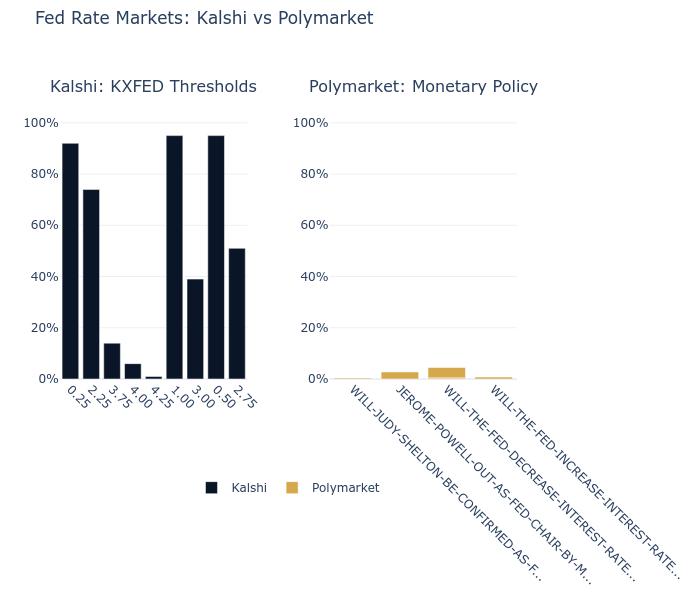

In [14]:
fig.update_yaxes(tickformat=".0%", range=[0, 1.05], row=1, col=1)
fig.update_yaxes(tickformat=".0%", range=[0, 1.05], row=1, col=2)
fig.update_xaxes(tickangle=45, row=1, col=1)
fig.update_xaxes(tickangle=45, row=1, col=2)

fig.update_layout(
    title=dict(text="Fed Rate Markets: Kalshi vs Polymarket", y=0.98),
    height=600,
    template="plotly_white",
    showlegend=True,
    legend=dict(orientation="h", yanchor="top", y=-0.35, xanchor="center", x=0.5),
    margin=dict(t=110, b=180, l=60, r=40),
)
# Push subplot titles down so the legend at the top of plot area can fit
for ann in fig.layout.annotations:
    ann.update(y=1.05)

fig.show()

Kalshi's threshold structure (rate above X%) provides a richer view of the
probability distribution over rate outcomes. Polymarket tends to structure
the same underlying event as separate yes/no questions. Both encode similar
information, but with different contract designs.

## 11. Volume Comparison

Both datasets expose provider-specific volume fields. The absolute units are
not directly comparable, but relative activity still helps identify which
contracts matter most within each platform.

Polymarket reports volume as USDC notional traded on the bar; Kalshi
reports daily contract count. The two are not directly comparable and
the table below should be read column-by-column to rank contracts
within each provider, not as a cross-provider volume ratio.

In [15]:
pl.DataFrame(
    {
        "provider": ["Polymarket (Fed)", "Kalshi (all KXFED)"],
        "volume": [
            fed_markets["total_volume"].sum(),
            kalshi_df["volume"].sum(),
        ],
        "unit": ["USDC notional (sum of bars)", "contracts (daily OHLCV sum)"],
    }
)

provider,volume,unit
str,f64,str
"""Polymarket (Fed)""",309.0,"""USDC notional (sum of bars)"""
"""Kalshi (all KXFED)""",315.0,"""contracts (daily OHLCV sum)"""


In [16]:
fed_markets.select("symbol", "total_volume", "avg_intraday_range").sort(
    "total_volume", descending=True
)

symbol,total_volume,avg_intraday_range
str,f64,f64
"""WILL-JUDY-SHELTON-BE-CONFIRMED…",62.0,0.0
"""JEROME-POWELL-OUT-AS-FED-CHAIR…",62.0,0.003
"""WILL-THE-FED-DECREASE-INTEREST…",62.0,0.0
"""WILL-THE-FED-INCREASE-INTEREST…",62.0,0.0
"""WILL-THE-FED-DECREASE-INTEREST…",61.0,0.0


Within each platform, the busiest contracts tend to be the most informative
because they aggregate more views and move more cleanly in response to new
information.

## 12. Event Indicators for ML

The downloaded OHLCV data supports simple event features: implied probability,
conviction, intraday range, and a high-confidence flag.

In [17]:
features = df.select(
    [
        "timestamp",
        "symbol",
        pl.col("market_category").alias("category"),
        "open",
        "high",
        "low",
        "close",
        "volume",
        "intraday_range",
        "conviction",
        "high_confidence",
    ]
)

print(f"Feature matrix: {features.shape}")

features.select(
    "timestamp",
    "symbol",
    "close",
    "conviction",
    "high_confidence",
    "intraday_range",
    "category",
).head(15)

Feature matrix: (22, 11)


timestamp,symbol,close,conviction,high_confidence,intraday_range,category
date,str,f64,f64,i8,f64,str
2026-05-02,"""BITCOIN-ABOVE-70K-ON-MAY-2:YES""",0.9995,0.4995,1,0.0,"""crypto"""
2026-05-02,"""BITCOIN-ABOVE-72K-ON-MAY-2:YES""",0.9985,0.4985,1,0.0,"""crypto"""
2026-05-01,"""BITCOIN-ABOVE-80K-ON-MAY-2:YES""",0.0275,0.4725,1,0.0,"""crypto"""
2026-05-02,"""BITCOIN-ABOVE-80K-ON-MAY-2:YES""",0.0445,0.4555,1,0.033,"""crypto"""
2026-05-02,"""BITCOIN-ABOVE-84K-ON-MAY-2:YES""",0.0015,0.4985,1,0.001,"""crypto"""
…,…,…,…,…,…,…
2026-05-02,"""WILL-JUDY-SHELTON-BE-CONFIRMED…",0.0035,0.4965,1,0.0,"""monetary_policy"""
2026-05-02,"""WILL-OPENAI-HAVE-THE-BEST-AI-M…",0.034,0.466,1,0.001,"""technology"""
2026-05-02,"""WILL-SPACEX-IPO-BY-MAY-31-2026…",0.0155,0.4845,1,0.0,"""science"""


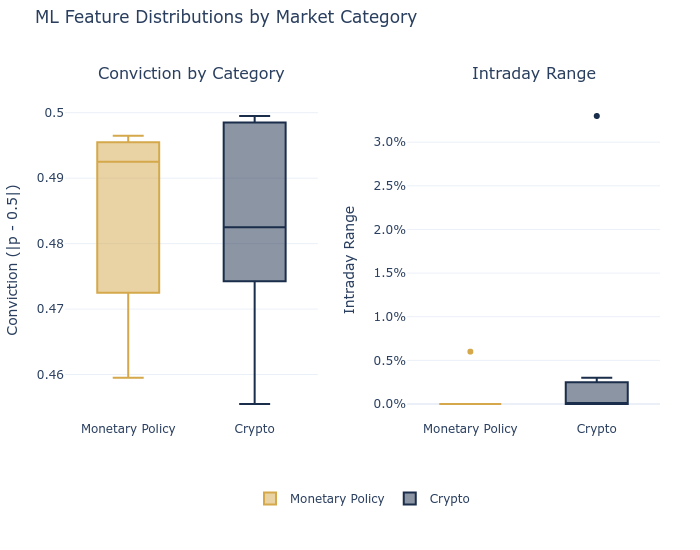

In [18]:
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Conviction by Category", "Intraday Range"),
    horizontal_spacing=0.15,
)

for cat in ["monetary_policy", "crypto", "commodities", "geopolitics"]:
    subset = features.filter(pl.col("category") == cat)
    if subset.is_empty():
        continue
    color = category_colors.get(cat, "#94a3b8")

    fig.add_trace(
        go.Box(
            y=subset["conviction"].to_list(),
            name=cat.replace("_", " ").title(),
            marker_color=color,
        ),
        row=1,
        col=1,
    )

    fig.add_trace(
        go.Box(
            y=subset["intraday_range"].to_list(),
            name=cat.replace("_", " ").title(),
            marker_color=color,
            showlegend=False,
        ),
        row=1,
        col=2,
    )

fig.update_yaxes(title_text="Conviction (|p - 0.5|)", row=1, col=1)
fig.update_yaxes(title_text="Intraday Range", tickformat=".1%", row=1, col=2)

fig.update_layout(
    title=dict(text="ML Feature Distributions by Market Category", y=0.98),
    height=550,
    template="plotly_white",
    legend=dict(orientation="h", yanchor="top", y=-0.2, xanchor="center", x=0.5),
    margin=dict(t=100, b=130, l=60, r=40),
)
for ann in fig.layout.annotations:
    ann.update(y=1.05)

fig.show()

Monetary policy markets tend to have high conviction (prices near 0 or 1)
because FOMC outcomes are well-anticipated. Crypto and commodity markets
show more dispersion — more opportunities for ML-driven signals.

## 13. Data Quality Assessment

In [19]:
quality = (
    features.group_by("category")
    .agg(
        pl.len().alias("n_markets"),
        pl.col("volume").mean().alias("avg_volume"),
        pl.col("intraday_range").mean().alias("avg_intraday_range"),
        pl.col("conviction").mean().alias("avg_conviction"),
        pl.col("high_confidence").mean().alias("pct_high_confidence"),
    )
    .sort("avg_volume", descending=True)
)
quality

category,n_markets,avg_volume,avg_intraday_range,avg_conviction,pct_high_confidence
str,u32,f64,f64,f64,f64
"""technology""",3,62.0,0.000333,0.487,1.0
"""science""",2,61.5,0.0,0.44725,1.0
"""crypto""",7,44.142857,0.005286,0.483786,1.0
"""monetary_policy""",10,30.9,0.0006,0.4837,1.0


## 14. Save Enriched Data

In [20]:
output_dir = get_output_dir(4, "polymarket")
output_dir.mkdir(parents=True, exist_ok=True)

output_file = output_dir / "polymarket_features.parquet"
features.write_parquet(output_file)

print(f"Saved {len(features)} Polymarket feature rows to {output_file}")

Saved 22 Polymarket feature rows to 04_fundamental_alternative_data/output/polymarket/polymarket_features.parquet


## Key Takeaways

1. **Centralized data path**: This notebook now uses the shared
   `data/prediction_markets/download.py` pipeline by default, matching the
   broader book workflow

2. **Downloaded OHLCV is enough for modeling**: Probability level, conviction,
   and intraday range are available without hitting the live API during notebook runs

3. **Optional live demo remains available**: Set `LIVE=True` for an interactive
   market-discovery demo when current Polymarket snapshots are the point

4. **Complementary platforms**: Kalshi provides richer threshold structure,
   while Polymarket adds a broader crypto-native event universe. Using both
   gives a more complete view

**Previous**: See [`12_kalshi_prediction_markets`](12_kalshi_prediction_markets.ipynb) for OHLCV time series
analysis using pre-downloaded Kalshi data.